# Lab 09: Classification using Kernal Machines (SVM)

Submitted By
* Name: Rakshitha V S
* Reg No : 2348448
* Class : 3 MDS B

**Importing Libraries**

Pandas: For organizing and analyzing data tables.

NumPy: For numerical operations and array manipulation.

Matplotlib: For creating basic graphs and charts.

Seaborn: For creating more visually appealing statistical graphics.

scipy: Used for statistical analysis and hypothesis testing.

In [ ]:
import pandas as pd
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Importing the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/advertising.csv')

# Data Exploration

### Data Description

- **TV:** This column represents the amount of money spent on advertising through TV channels. It indicates the financial investment in television advertising for each instance.

- **Radio:** This column represents the advertising expenditure on radio. It shows how much money is allocated to radio advertising for each case.

- **Newspaper:** This column represents the advertising expenditure in newspapers. It indicates the financial investment in newspaper advertising for each instance.

- **Sales:** This column represents the sales generated as a result of the advertising expenditures in TV, Radio, and Newspaper. It shows the outcome variable that is being analyzed or predicted.

The dataset contains information about advertising expenditures across different channels (TV, Radio, Newspaper) and the corresponding sales outcomes. The goal is to analyze the relationship between advertising spending and sales, potentially building a predictive model or understanding which advertising channels contribute more to sales.

In [ ]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [ ]:
print(f"The shape of the data is: {df.shape}")
print(f"The size of the data is: {df.size}")

The shape of the data is: (200, 4)
The size of the data is: 800


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


# Univariate Analysis

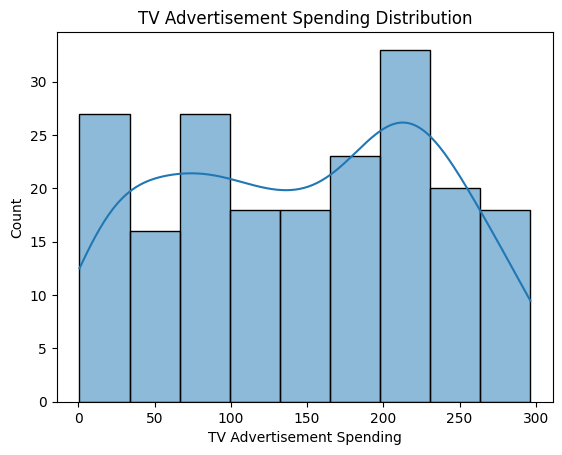

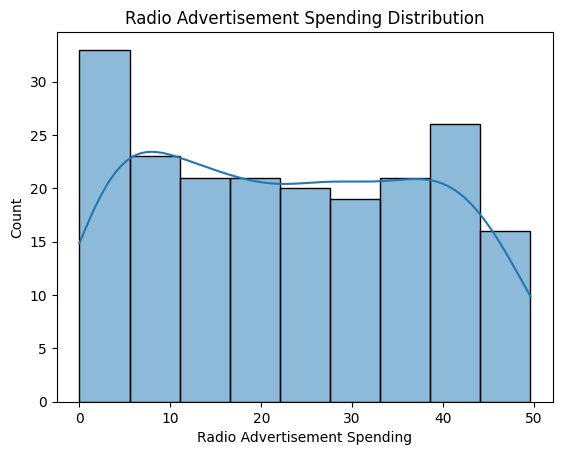

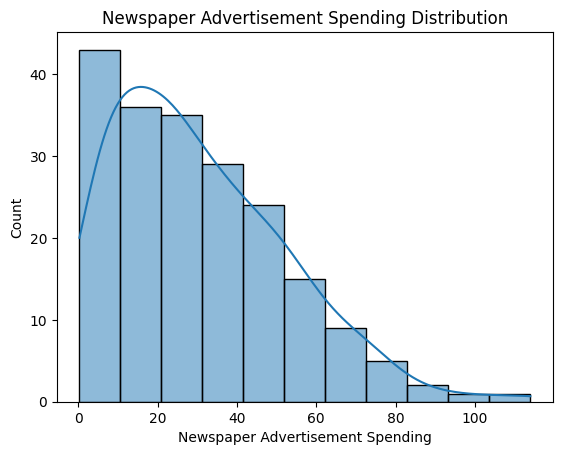

In [ ]:
# Visualize numerical variables distributions

sns.histplot(data=df, x='TV', kde=True)
plt.title('TV Advertisement Spending Distribution')
plt.xlabel('TV Advertisement Spending')
plt.show()

sns.histplot(data=df, x='Radio', kde=True)
plt.title('Radio Advertisement Spending Distribution')
plt.xlabel('Radio Advertisement Spending')
plt.show()

sns.histplot(data=df, x='Newspaper', kde=True)
plt.title('Newspaper Advertisement Spending Distribution')
plt.xlabel('Newspaper Advertisement Spending')
plt.show()

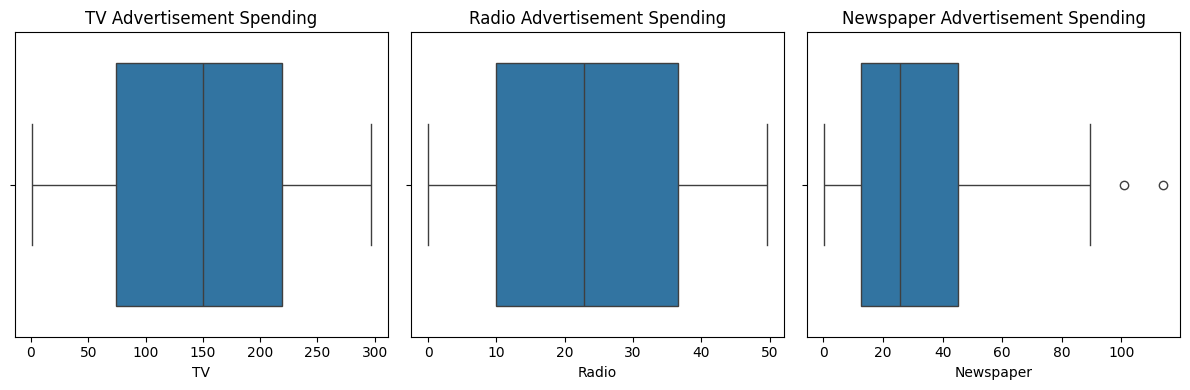

In [ ]:
# Create box plots for numerical variables
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='TV')
plt.title('TV Advertisement Spending')

plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Radio')
plt.title('Radio Advertisement Spending')

plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Newspaper')
plt.title('Newspaper Advertisement Spending')

plt.tight_layout()
plt.show()


**INFERENCE:**Here, we can see that for TV the minimum is 0.7 and maximum is 298 ,no outliers are present.For Radio the minimum is 0.7 and maximium is 48,no outliers.For Newspaper the minimum is 0.7 and maximum is 90,outliers are present.

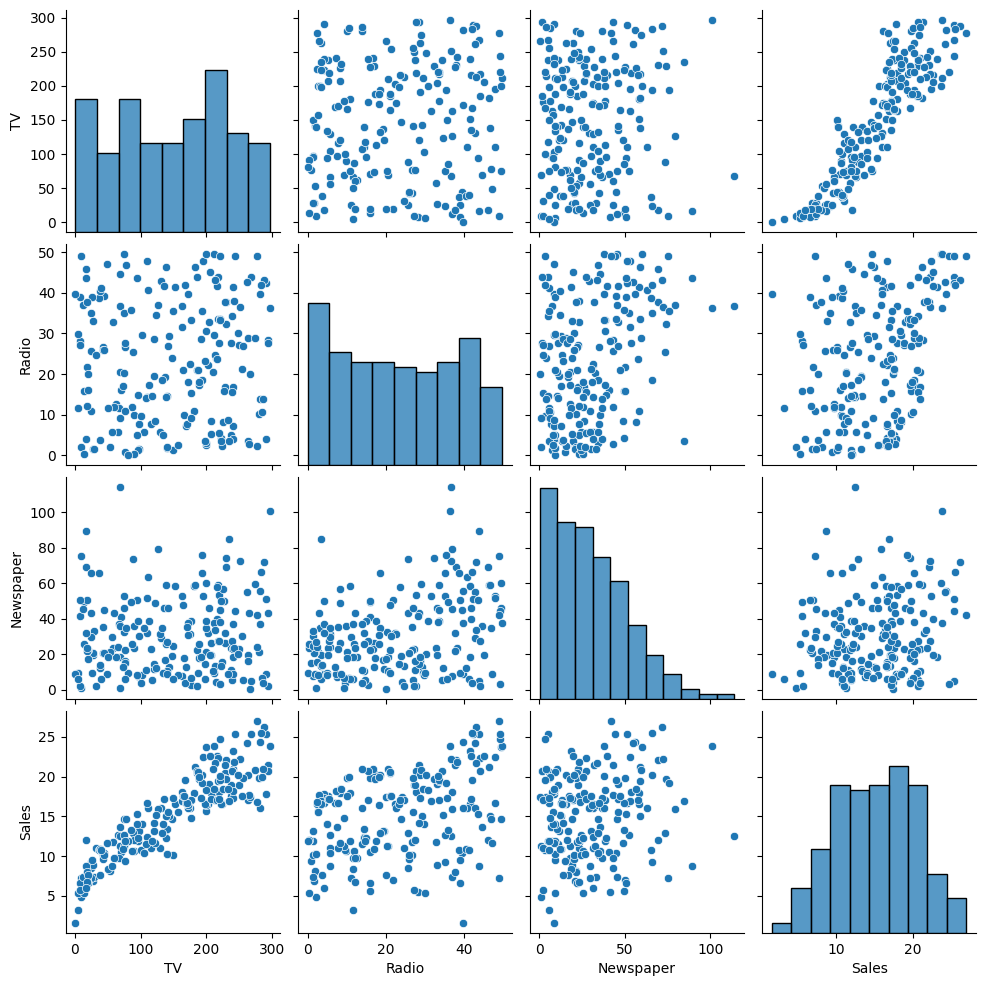

In [ ]:
# Bivariate Analysis
# Scatter plots for numerical variables
sns.pairplot(df)
plt.show()

**INFERENCE:** Here we can see that TV and sales are showing a positive linear correlation.

In [ ]:
# Correlation coefficients between numerical variables
correlation_matrix = df.corr()
print(correlation_matrix)

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


<Axes: >

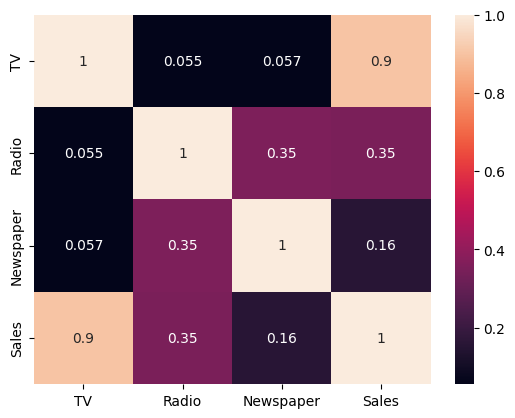

In [ ]:
sns.heatmap(correlation_matrix,annot=True)

#Classification using Kernal Machines

In [ ]:
# Separate features (X) and target variable (y)
X = df.drop(columns=['Sales'])
y = df['Sales']

In [ ]:
# Standardization or normalization on the features as required
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Train the SVM model using the training data
svm_model = SVR(kernel='linear')
svm_model.fit(X_train, y_train)

SVR(kernel='linear')

In [ ]:
# Evaluate the performance of the trained model
y_pred = svm_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 2.8406109485551676
R2 Score: 0.9080741155313187


In [ ]:
# Display the classification report and confusion matrix
# SVM is used for regression, not classification, so there's no classification report or confusion matrix.

# Explore different kernel functions and tune hyperparameters
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    svm_model = SVR(kernel=kernel)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print("Kernel:", kernel)
    print("Mean Squared Error:", mse)
    print("R2 Score:", r2)

Kernel: linear
Mean Squared Error: 2.8406109485551676
R2 Score: 0.9080741155313187
Kernel: poly
Mean Squared Error: 5.58647909416366
R2 Score: 0.8192142320446955
Kernel: rbf
Mean Squared Error: 4.3034465802338095
R2 Score: 0.8607348417941818


**INFERENCE:**Here, we can see that linear kernal function has higher R2_score than the R2_score of rbf which is greater than poly.Therefore, we will take linear kernal for this dataset.

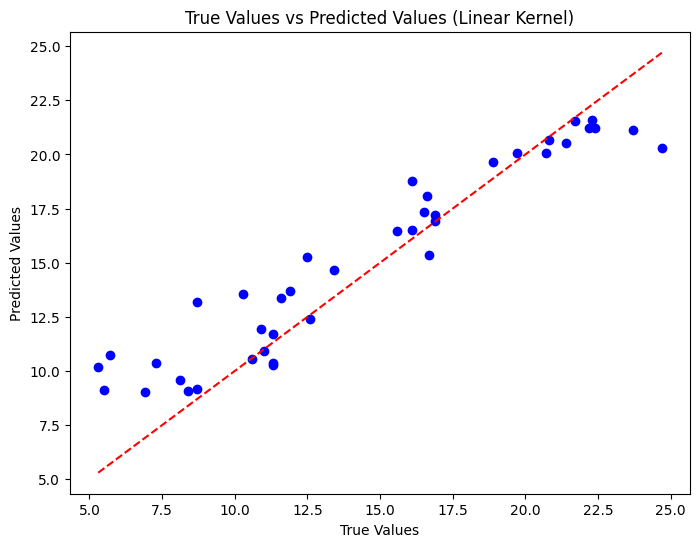

In [ ]:
import numpy as np

# Plotting the true values vs predicted values for the linear SVM model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('True Values vs Predicted Values (Linear Kernel)')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.show()


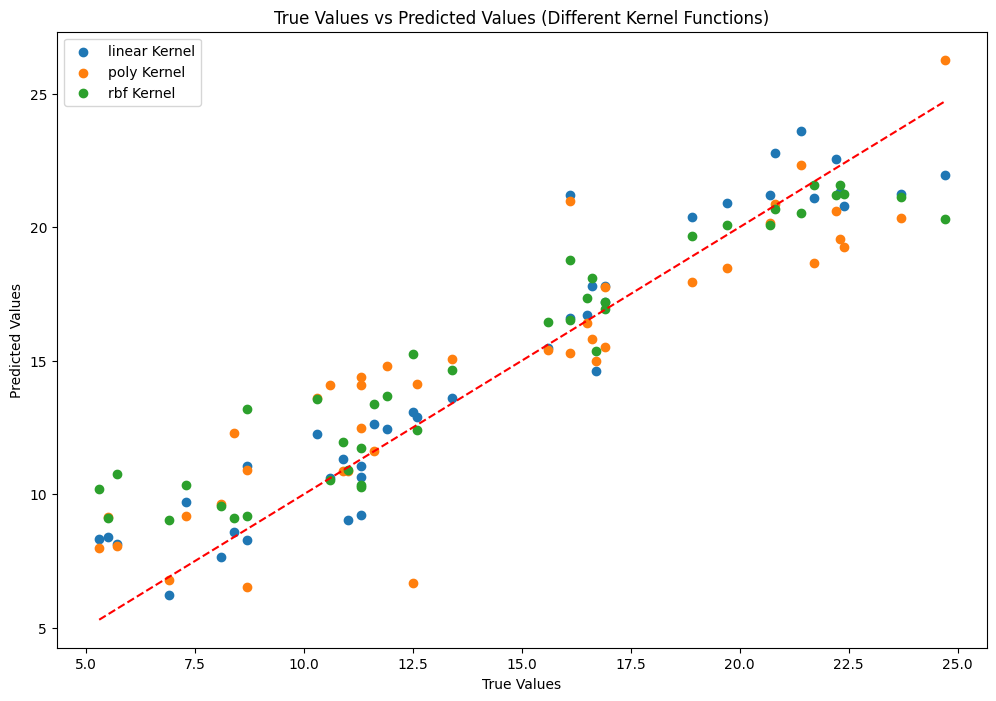

In [ ]:
# Plotting the true values vs predicted values for SVM models with different kernel functions
plt.figure(figsize=(12, 8))

for kernel in kernels:
    svm_model = SVR(kernel=kernel)
    svm_model.fit(X_train, y_train)
    y_pred = svm_model.predict(X_test)
    plt.scatter(y_test, y_pred, label=f'{kernel} Kernel')

plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('True Values vs Predicted Values (Different Kernel Functions)')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()

#CONCLUSION


For the given dataset, we can conclude that a linear kernel is best suited for fitting. Therefore, using the linear kernel, we can fit the model to predict sales based on different advertising budgets.